In [4]:
import scipy.io
import numpy as np

# Specify the path to your .mat file
mat_file_path = r'single_trail_decoding\movie1_trial1.mat'  # Replace with actual path if needed

try:
    data = scipy.io.loadmat(mat_file_path)
    print("Keys in the .mat file:")
    for key in data.keys():
        if not key.startswith('__'):  # Skip metadata keys like '__header__', '__version__', etc.
            print(f"Key: {key}, Shape: {data[key].shape}")
    
    # Output max and min for 'movie' key
    if 'movie' in data:
        movie_data = data['movie']
        max_val = np.max(movie_data)
        min_val = np.min(movie_data)
        print(f"Movie data max: {max_val}, min: {min_val}")
except Exception as e:
    print(f"Error loading file: {e}")

Keys in the .mat file:
Key: movie, Shape: (900, 304, 608)
Key: spike_single, Shape: (444, 900)
Movie data max: 1.0, min: 0.0


In [2]:
# Check GPU
import tensorflow as tf
devices = tf.config.list_physical_devices('GPU')  
if devices:
    print(f"Using GPU: {devices}")
else:
    print("Not using GPU. Using CPU instead.")

Not using GPU. Using CPU instead.


In [3]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


In [5]:
# CNN
path01 = r'CNN\results\movie\movie01\test_metrics.json'
path02 = r'CNN\results\movie\movie03\test_metrics.json'
path03 = r'CNN\results\allensdk_30\movie1\test_metrics.json'
path04 = r'CNN\results\allensdk_30\movie3\test_metrics.json'
path05 = r'CNN\results\allensdk_22\movie1\test_metrics.json'
path06 = r'CNN\results\allensdk_22\movie3\test_metrics.json'

# LN
path11 = r'LN\results\movie\movie01\test_metrics.json'
path12 = r'LN\results\movie\movie03\test_metrics.json'
path13 = r'LN\results\allensdk_30\movie1\test_metrics.json'
path14 = r'LN\results\allensdk_30\movie3\test_metrics.json'
path15 = r'LN\results\allensdk_22\movie1\test_metrics.json'
path16 = r'LN\results\allensdk_22\movie3\test_metrics.json'

# GLM
path21 = r'GLM\results\movie\movie01\test_metrics.json'
path22 = r'GLM\results\movie\movie03\test_metrics.json'
path23 = r'GLM\results\allensdk_30\movie1\test_metrics.json'
path24 = r'GLM\results\allensdk_30\movie3\test_metrics.json'
path25 = r'GLM\results\allensdk_22\movie1\test_metrics.json'
path26 = r'GLM\results\allensdk_22\movie3\test_metrics.json'

result_path = 'Encoding_results_summary.md'

import json
import os

# 定义模型和路径列表
models = ['CNN', 'LN', 'GLM']
dataset_to_paths = {
    'movie01': {'CNN': path01, 'LN': path11, 'GLM': path21},
    'movie03': {'CNN': path02, 'LN': path12, 'GLM': path22},
    'allensdk_30_movie1': {'CNN': path03, 'LN': path13, 'GLM': path23},
    'allensdk_30_movie3': {'CNN': path04, 'LN': path14, 'GLM': path24},
    'allensdk_22_movie1': {'CNN': path05, 'LN': path15, 'GLM': path25},
    'allensdk_22_movie3': {'CNN': path06, 'LN': path16, 'GLM': path26}
}
datasets = list(dataset_to_paths.keys())

# 读取数据并构建表格
table_rows = []
for dataset in datasets:
    for model in models:
        path = dataset_to_paths[dataset][model]
        if os.path.exists(path):
            with open(path, 'r') as f:
                data = json.load(f)
            cc = data.get('cc', None)
            if cc is not None:
                table_rows.append(f"| {dataset} | {model} | {cc:.4f} |")
            
        else:
            print(f"File not found: {path}")

# 生成 Markdown 表格
markdown_content = "# Encoding Results Summary\n\n"
markdown_content += "| Dataset | Model | CC |\n"
markdown_content += "|---------|-------|----|\n"
for row in table_rows:
    markdown_content += row + "\n"

# 写入文件
with open(result_path, 'w') as f:
    f.write(markdown_content)

print(f"Table written to {result_path}")

Table written to Encoding_results_summary.md


In [ ]:
# 合并单元：解码、保存图像、生成对比图，并绘制三项指标柱状图
import scipy.io
import numpy as np
import cv2
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
from keras.models import load_model
from SID.SID import cal_performance
import json
import re
import math

# --- 配置路径 ---
decoder_path = r'Neural_digit_twin\\group1_movie3_only\\decoder_group1_best.keras'
data_path = r'Dataset\\allenSDK\\session_721123822\\movie1.mat'
output_dir = Path(r'Neural_digit_twin\\group1_movie3_only\\movie1_reconstruction_combined')
output_dir.mkdir(parents=True, exist_ok=True)

# --- 1. 加载数据 ---
print("加载数据...")
data = scipy.io.loadmat(data_path)
if 'spike' in data:
    spike = data['spike'].astype(np.float32)
elif 'spike_single' in data:
    spike = data['spike_single'].T.astype(np.float32)
else:
    raise KeyError(f"Missing key 'spike'/'spike_single' in {data_path}")

movie = data['movie'].astype(np.float32)
print(f"Spike shape: {spike.shape}, Movie shape: {movie.shape}")

# --- 2. 加载模型并预测 ---
print("加载模型并进行预测...")
model = load_model(decoder_path)
pred_movie = model.predict(spike, batch_size=256, verbose=1)
print(f"预测图像 shape: {pred_movie.shape}")

# --- 3. 计算性能指标（与保存） ---
print("计算性能指标...")
def resize_images(images, res):
    resized = np.zeros((images.shape[0], res, res))
    for i in range(images.shape[0]):
        resized[i] = cv2.resize(images[i], (res, res))
    return resized.reshape((images.shape[0], res, res, 1))

movie_resized = resize_images(movie, 64)
# 确保 pred_movie 与 movie_resized 形状兼容
pred_for_metric = pred_movie
if pred_for_metric.ndim == 2:
    # 可能是展平输出，尝试 reshape
    pred_for_metric = pred_for_metric.reshape((-1, 64, 64, 1))
elif pred_for_metric.ndim == 3:
    # (N, H, W) -> (N, H, W, 1)
    pred_for_metric = np.expand_dims(pred_for_metric, -1)

mse, psnr, ssim = cal_performance(movie_resized, pred_for_metric)
print(f"MSE: {mse:.6f}, PSNR: {psnr:.6f}, SSIM: {ssim:.6f}")

metrics = {"mse": float(mse), "psnr": float(psnr), "ssim": float(ssim)}
metrics_path = output_dir / 'test_metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=4)
print(f"Metrics saved to {metrics_path}")

# --- 4. 保存原始和重建图像 ---
print("保存图像...")
original_dir = output_dir / 'original_images'
reconstructed_dir = output_dir / 'reconstructed_images'
original_dir.mkdir(exist_ok=True)
reconstructed_dir.mkdir(exist_ok=True)

for idx in range(len(movie)):
    orig_img = cv2.resize(movie[idx], (64, 64))
    plt.imsave(original_dir / f'frame_{idx:04d}.png', orig_img, cmap='gray')
    recon_img = pred_movie[idx]
    # 处理可能的维度
    if recon_img.ndim == 3 and recon_img.shape[-1] == 1:
        recon = recon_img.squeeze(-1)
    else:
        recon = np.squeeze(recon_img)
    plt.imsave(reconstructed_dir / f'frame_{idx:04d}.png', recon, cmap='gray')

print(f"Images saved: {len(movie)} frames in {original_dir} and {reconstructed_dir}")

# --- 5. 生成两行对比图（原始 / 重建）并保存 PDF ---
print("生成对比图 PDF...")
# 获取对齐帧
row_specs = [('原始图像', original_dir), ('重建图像', reconstructed_dir)]
common_files = None
for _, folder in row_specs:
    names = {p.name for p in folder.glob('frame_*.png')}
    common_files = names if common_files is None else common_files & names
if not common_files:
    raise FileNotFoundError('未找到可对齐的 frame_*.png 图像文件。')

def frame_key(name):
    m = re.search(r'frame_(\d+)\.png$', name)
    return int(m.group(1)) if m else math.inf

common_list = sorted(common_files, key=frame_key)
num_to_show = min(8, len(common_list))
selected = common_list[:num_to_show]

fig, axes = plt.subplots(nrows=2, ncols=len(selected) + 1, figsize=(2.0 * (len(selected) + 1), 4.5), dpi=200,
                         gridspec_kw={'width_ratios':[1.25] + [1]*len(selected)})
label_font='Microsoft YaHei'
label_size=14
for row_idx, (label, folder) in enumerate(row_specs):
    lab_ax = axes[row_idx,0]
    lab_ax.axis('off')
    lab_ax.text(0.5,0.5,label,ha='center',va='center',fontsize=label_size,fontweight='bold',fontname=label_font)
    for col_idx, name in enumerate(selected, start=1):
        ax = axes[row_idx, col_idx]
        ax.axis('off')
        img = Image.open(folder / name).convert('RGB')
        if row_idx == 0:
            img = img.resize((64,64), Image.Resampling.LANCZOS)
        ax.imshow(img)

plt.subplots_adjust(left=0.02,right=0.995,top=0.99,bottom=0.01,wspace=0.02,hspace=0.02)
comp_pdf = output_dir / 'movie1_reconstruction_comparison_two_rows.pdf'
fig.savefig(comp_pdf, dpi=300, bbox_inches='tight')
plt.show()
print(f'Comparison PDF saved to: {comp_pdf}')


加载数据...
Spike shape: (890, 444), Movie shape: (890, 304, 608)
加载模型并进行预测...
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step
预测图像 shape: (890, 64, 64, 1)
计算性能指标...
MSE: 0.047664, PSNR: 13.385520, SSIM: 0.169291
Metrics saved to Neural_digit_twin\group1_movie3_only\movie1_reconstruction_combined\test_metrics.json
保存图像...
Images saved: 890 frames in Neural_digit_twin\group1_movie3_only\movie1_reconstruction_combined\original_images and Neural_digit_twin\group1_movie3_only\movie1_reconstruction_combined\reconstructed_images
生成对比图 PDF...


C:\Users\tjh20\AppData\Local\Temp\ipykernel_38412\2913470940.py:124: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
C:\Users\tjh20\AppData\Local\Temp\ipykernel_38412\2913470940.py:145: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes2[0].set_xticklabels(models, rotation=30, ha='right')
C:\Users\tjh20\AppData\Local\Temp\ipykernel_38412\2913470940.py:150: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes2[1].set_xticklabels(models, rotation=30, ha='right')
C:\Users\tjh20\AppData\Local\Temp\ipykernel_38412\2913470940.py:155: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes2[2].set_xticklabels(models, rotation=30, ha='right')


Comparison PDF saved to: Neural_digit_twin\group1_movie3_only\movie1_reconstruction_combined\movie1_reconstruction_comparison_two_rows.pdf
绘制指标柱状图...
Metrics bar plots saved to: Neural_digit_twin\group1_movie3_only\movie1_reconstruction_combined\metrics_bars.pdf


C:\Users\tjh20\AppData\Local\Temp\ipykernel_38412\2913470940.py:164: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [1]:
# Group2: 解码、保存图像、生成对比图
import scipy.io
import numpy as np
import cv2
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
from keras.models import load_model
from SID.SID import cal_performance
import json
import re
import math

# --- 配置路径（Group2） ---
decoder_path = r'Neural_digit_twin\group2_movie3_plus_movie1_real\decoder_group2_best.keras'
data_path = r'Dataset\allenSDK\session_721123822\movie1.mat'
output_dir = Path(r'Neural_digit_twin\group2_movie3_plus_movie1_real\movie1_reconstruction')
output_dir.mkdir(parents=True, exist_ok=True)

# --- 1. 加载数据 ---
print("=== Group2: 加载数据 ===")
data = scipy.io.loadmat(data_path)
if 'spike' in data:
    spike = data['spike'].astype(np.float32)
elif 'spike_single' in data:
    spike = data['spike_single'].T.astype(np.float32)
else:
    raise KeyError(f"Missing key 'spike'/'spike_single' in {data_path}")

movie = data['movie'].astype(np.float32)
print(f"Spike shape: {spike.shape}, Movie shape: {movie.shape}")

# --- 2. 加载模型并预测 ---
print("加载模型并进行预测...")
model = load_model(decoder_path)
pred_movie = model.predict(spike, batch_size=256, verbose=1)
print(f"预测图像 shape: {pred_movie.shape}")

# --- 3. 计算性能指标 ---
print("计算性能指标...")
def resize_images(images, res):
    resized = np.zeros((images.shape[0], res, res))
    for i in range(images.shape[0]):
        resized[i] = cv2.resize(images[i], (res, res))
    return resized.reshape((images.shape[0], res, res, 1))

movie_resized = resize_images(movie, 64)
pred_for_metric = pred_movie
if pred_for_metric.ndim == 2:
    pred_for_metric = pred_for_metric.reshape((-1, 64, 64, 1))
elif pred_for_metric.ndim == 3:
    pred_for_metric = np.expand_dims(pred_for_metric, -1)

mse, psnr, ssim = cal_performance(movie_resized, pred_for_metric)
print(f"MSE: {mse:.6f}, PSNR: {psnr:.6f}, SSIM: {ssim:.6f}")

metrics = {"mse": float(mse), "psnr": float(psnr), "ssim": float(ssim)}
metrics_path = output_dir / 'test_metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=4)
print(f"Metrics saved to {metrics_path}")

# --- 4. 保存原始和重建图像 ---
print("保存图像...")
original_dir = output_dir / 'original_images'
reconstructed_dir = output_dir / 'reconstructed_images'
original_dir.mkdir(exist_ok=True)
reconstructed_dir.mkdir(exist_ok=True)

for idx in range(len(movie)):
    orig_img = cv2.resize(movie[idx], (64, 64))
    plt.imsave(original_dir / f'frame_{idx:04d}.png', orig_img, cmap='gray')
    recon_img = pred_movie[idx]
    if recon_img.ndim == 3 and recon_img.shape[-1] == 1:
        recon = recon_img.squeeze(-1)
    else:
        recon = np.squeeze(recon_img)
    plt.imsave(reconstructed_dir / f'frame_{idx:04d}.png', recon, cmap='gray')

print(f"Images saved: {len(movie)} frames in {original_dir} and {reconstructed_dir}")

# --- 5. 生成两行对比图 ---
print("生成对比图 PDF...")
row_specs = [('原始图像', original_dir), ('重建图像', reconstructed_dir)]
common_files = None
for _, folder in row_specs:
    names = {p.name for p in folder.glob('frame_*.png')}
    common_files = names if common_files is None else common_files & names
if not common_files:
    raise FileNotFoundError('未找到可对齐的 frame_*.png 图像文件。')

def frame_key(name):
    m = re.search(r'frame_(\d+)\.png$', name)
    return int(m.group(1)) if m else math.inf

common_list = sorted(common_files, key=frame_key)
num_to_show = min(8, len(common_list))
selected = common_list[:num_to_show]

fig, axes = plt.subplots(nrows=2, ncols=len(selected) + 1, figsize=(2.0 * (len(selected) + 1), 4.5), dpi=200,
                         gridspec_kw={'width_ratios':[1.25] + [1]*len(selected)})
label_font='Microsoft YaHei'
label_size=14
for row_idx, (label, folder) in enumerate(row_specs):
    lab_ax = axes[row_idx,0]
    lab_ax.axis('off')
    lab_ax.text(0.5,0.5,label,ha='center',va='center',fontsize=label_size,fontweight='bold',fontname=label_font)
    for col_idx, name in enumerate(selected, start=1):
        ax = axes[row_idx, col_idx]
        ax.axis('off')
        img = Image.open(folder / name).convert('RGB')
        if row_idx == 0:
            img = img.resize((64,64), Image.Resampling.LANCZOS)
        ax.imshow(img)

plt.subplots_adjust(left=0.02,right=0.995,top=0.99,bottom=0.01,wspace=0.02,hspace=0.02)
comp_pdf = output_dir / 'movie1_reconstruction_comparison_two_rows.pdf'
fig.savefig(comp_pdf, dpi=300, bbox_inches='tight')
plt.close(fig)
print(f'Group2 Comparison PDF saved to: {comp_pdf}')


=== Group2: 加载数据 ===
Spike shape: (890, 444), Movie shape: (890, 304, 608)
加载模型并进行预测...
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step
预测图像 shape: (890, 64, 64, 1)
计算性能指标...
MSE: 0.013950, PSNR: 19.112937, SSIM: 0.477727
Metrics saved to Neural_digit_twin\group2_movie3_plus_movie1_real\movie1_reconstruction\test_metrics.json
保存图像...
Images saved: 890 frames in Neural_digit_twin\group2_movie3_plus_movie1_real\movie1_reconstruction\original_images and Neural_digit_twin\group2_movie3_plus_movie1_real\movie1_reconstruction\reconstructed_images
生成对比图 PDF...
Group2 Comparison PDF saved to: Neural_digit_twin\group2_movie3_plus_movie1_real\movie1_reconstruction\movie1_reconstruction_comparison_two_rows.pdf


In [2]:
# Group3: 解码、保存图像、生成对比图
import scipy.io
import numpy as np
import cv2
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
from keras.models import load_model
from SID.SID import cal_performance
import json
import re
import math

# --- 配置路径（Group3） ---
decoder_path = r'Neural_digit_twin\group3_pretrain_generated_then_finetune_real\decoder_group3_finetune_best.keras'
data_path = r'Dataset\allenSDK\session_721123822\movie1.mat'
output_dir = Path(r'Neural_digit_twin\group3_pretrain_generated_then_finetune_real\movie1_reconstruction')
output_dir.mkdir(parents=True, exist_ok=True)

# --- 1. 加载数据 ---
print("=== Group3: 加载数据 ===")
data = scipy.io.loadmat(data_path)
if 'spike' in data:
    spike = data['spike'].astype(np.float32)
elif 'spike_single' in data:
    spike = data['spike_single'].T.astype(np.float32)
else:
    raise KeyError(f"Missing key 'spike'/'spike_single' in {data_path}")

movie = data['movie'].astype(np.float32)
print(f"Spike shape: {spike.shape}, Movie shape: {movie.shape}")

# --- 2. 加载模型并预测 ---
print("加载模型并进行预测...")
model = load_model(decoder_path)
pred_movie = model.predict(spike, batch_size=256, verbose=1)
print(f"预测图像 shape: {pred_movie.shape}")

# --- 3. 计算性能指标 ---
print("计算性能指标...")
def resize_images(images, res):
    resized = np.zeros((images.shape[0], res, res))
    for i in range(images.shape[0]):
        resized[i] = cv2.resize(images[i], (res, res))
    return resized.reshape((images.shape[0], res, res, 1))

movie_resized = resize_images(movie, 64)
pred_for_metric = pred_movie
if pred_for_metric.ndim == 2:
    pred_for_metric = pred_for_metric.reshape((-1, 64, 64, 1))
elif pred_for_metric.ndim == 3:
    pred_for_metric = np.expand_dims(pred_for_metric, -1)

mse, psnr, ssim = cal_performance(movie_resized, pred_for_metric)
print(f"MSE: {mse:.6f}, PSNR: {psnr:.6f}, SSIM: {ssim:.6f}")

metrics = {"mse": float(mse), "psnr": float(psnr), "ssim": float(ssim)}
metrics_path = output_dir / 'test_metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=4)
print(f"Metrics saved to {metrics_path}")

# --- 4. 保存原始和重建图像 ---
print("保存图像...")
original_dir = output_dir / 'original_images'
reconstructed_dir = output_dir / 'reconstructed_images'
original_dir.mkdir(exist_ok=True)
reconstructed_dir.mkdir(exist_ok=True)

for idx in range(len(movie)):
    orig_img = cv2.resize(movie[idx], (64, 64))
    plt.imsave(original_dir / f'frame_{idx:04d}.png', orig_img, cmap='gray')
    recon_img = pred_movie[idx]
    if recon_img.ndim == 3 and recon_img.shape[-1] == 1:
        recon = recon_img.squeeze(-1)
    else:
        recon = np.squeeze(recon_img)
    plt.imsave(reconstructed_dir / f'frame_{idx:04d}.png', recon, cmap='gray')

print(f"Images saved: {len(movie)} frames in {original_dir} and {reconstructed_dir}")

# --- 5. 生成两行对比图 ---
print("生成对比图 PDF...")
row_specs = [('原始图像', original_dir), ('重建图像', reconstructed_dir)]
common_files = None
for _, folder in row_specs:
    names = {p.name for p in folder.glob('frame_*.png')}
    common_files = names if common_files is None else common_files & names
if not common_files:
    raise FileNotFoundError('未找到可对齐的 frame_*.png 图像文件。')

def frame_key(name):
    m = re.search(r'frame_(\d+)\.png$', name)
    return int(m.group(1)) if m else math.inf

common_list = sorted(common_files, key=frame_key)
num_to_show = min(8, len(common_list))
selected = common_list[:num_to_show]

fig, axes = plt.subplots(nrows=2, ncols=len(selected) + 1, figsize=(2.0 * (len(selected) + 1), 4.5), dpi=200,
                         gridspec_kw={'width_ratios':[1.25] + [1]*len(selected)})
label_font='Microsoft YaHei'
label_size=14
for row_idx, (label, folder) in enumerate(row_specs):
    lab_ax = axes[row_idx,0]
    lab_ax.axis('off')
    lab_ax.text(0.5,0.5,label,ha='center',va='center',fontsize=label_size,fontweight='bold',fontname=label_font)
    for col_idx, name in enumerate(selected, start=1):
        ax = axes[row_idx, col_idx]
        ax.axis('off')
        img = Image.open(folder / name).convert('RGB')
        if row_idx == 0:
            img = img.resize((64,64), Image.Resampling.LANCZOS)
        ax.imshow(img)

plt.subplots_adjust(left=0.02,right=0.995,top=0.99,bottom=0.01,wspace=0.02,hspace=0.02)
comp_pdf = output_dir / 'movie1_reconstruction_comparison_two_rows.pdf'
fig.savefig(comp_pdf, dpi=300, bbox_inches='tight')
plt.close(fig)
print(f'Group3 Comparison PDF saved to: {comp_pdf}')


=== Group3: 加载数据 ===
Spike shape: (890, 444), Movie shape: (890, 304, 608)
加载模型并进行预测...
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step
预测图像 shape: (890, 64, 64, 1)
计算性能指标...
MSE: 0.011043, PSNR: 20.533748, SSIM: 0.585934
Metrics saved to Neural_digit_twin\group3_pretrain_generated_then_finetune_real\movie1_reconstruction\test_metrics.json
保存图像...
Images saved: 890 frames in Neural_digit_twin\group3_pretrain_generated_then_finetune_real\movie1_reconstruction\original_images and Neural_digit_twin\group3_pretrain_generated_then_finetune_real\movie1_reconstruction\reconstructed_images
生成对比图 PDF...
Group3 Comparison PDF saved to: Neural_digit_twin\group3_pretrain_generated_then_finetune_real\movie1_reconstruction\movie1_reconstruction_comparison_two_rows.pdf


找到 890 个公共帧，随机选择展示 8 帧
Four-row comparison PDF saved to: Neural_digit_twin\comparison_all_groups\four_row_comparison_all_groups.pdf


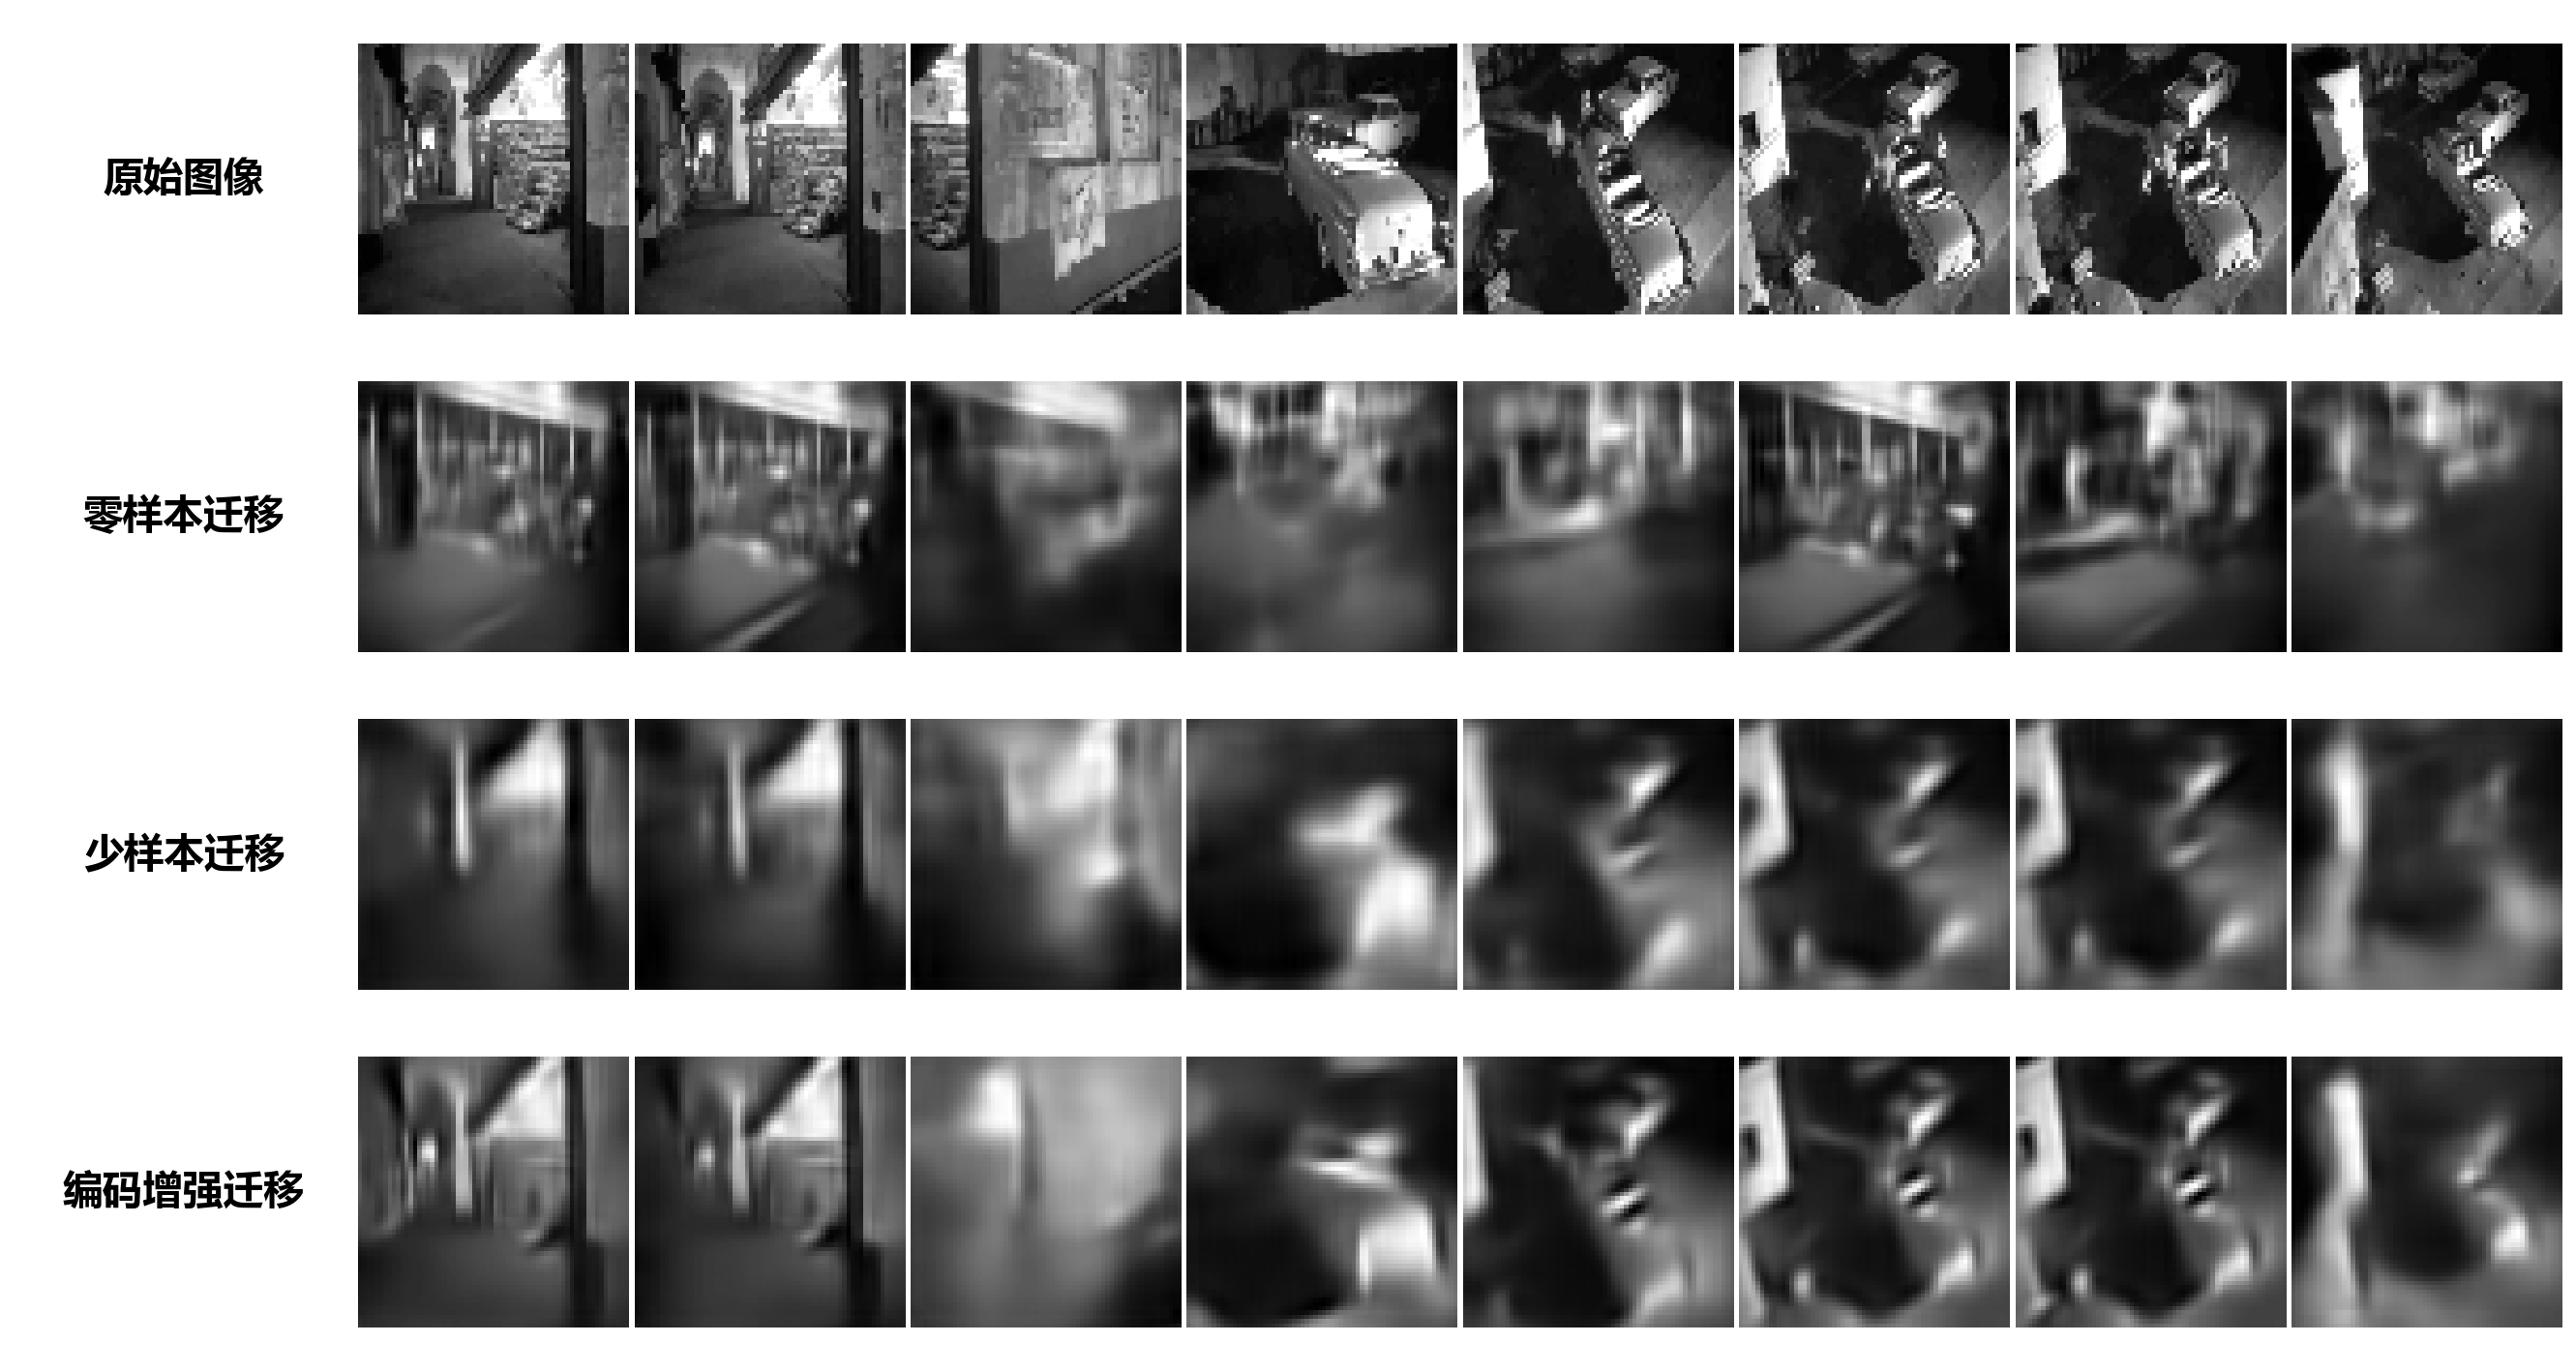

对比图已显示完成


In [5]:
# 四行对比图：原始图像 + Group1/Group2/Group3 重建图像（对齐）
import re
import math
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# --- 配置路径 ---
original_dir = Path(r'Neural_digit_twin\group1_movie3_only\movie1_reconstruction_combined\original_images')
group1_dir = Path(r'Neural_digit_twin\group1_movie3_only\movie1_reconstruction_combined\reconstructed_images')
group2_dir = Path(r'Neural_digit_twin\group2_movie3_plus_movie1_real\movie1_reconstruction\reconstructed_images')
group3_dir = Path(r'Neural_digit_twin\group3_pretrain_generated_then_finetune_real\movie1_reconstruction\reconstructed_images')

output_dir = Path(r'Neural_digit_twin\comparison_all_groups')
output_dir.mkdir(parents=True, exist_ok=True)

row_specs = [
    ('原始图像', original_dir),
    ('零样本迁移', group1_dir),
    ('少样本迁移', group2_dir),
    ('编码增强迁移', group3_dir),
]

# --- 获取四个目录中的公共文件名 ---
common_files = None
for _, folder in row_specs:
    names = {p.name for p in folder.glob('frame_*.png')}
    common_files = names if common_files is None else common_files & names

if not common_files:
    raise FileNotFoundError('未找到四个目录中都有的 frame_*.png 图像文件。')

def frame_key(name):
    m = re.search(r'frame_(\d+)\.png$', name)
    return int(m.group(1)) if m else math.inf

# 按帧号排序并随机选择 8 帧展示
common_list = sorted(common_files, key=frame_key)
num_to_show = min(8, len(common_list))
rng = np.random.default_rng()
selected = sorted(rng.choice(common_list, size=num_to_show, replace=False).tolist(), key=frame_key)

print(f"找到 {len(common_files)} 个公共帧，随机选择展示 {num_to_show} 帧")

# --- 创建四行对比图 ---
fig, axes = plt.subplots(
    nrows=len(row_specs),
    ncols=num_to_show + 1,
    figsize=(2.0 * (num_to_show + 1), 2.35 * len(row_specs)),
    dpi=150,
    gridspec_kw={'width_ratios': [1.25] + [1] * num_to_show, 'wspace': 0.02, 'hspace': 0.02}
 )

label_font = 'Microsoft YaHei'
label_size = 20

# 绘制四行
for row_idx, (row_label, folder) in enumerate(row_specs):
    # 第一列：标签
    label_ax = axes[row_idx, 0]
    label_ax.axis('off')
    label_ax.text(
        0.5, 0.5, row_label,
        ha='center', va='center',
        fontsize=label_size, fontweight='bold', fontname=label_font
    )
    
    # 后续列：对应的图像
    for col_idx, name in enumerate(selected, start=1):
        ax = axes[row_idx, col_idx]
        ax.axis('off')
        img_path = folder / name
        img = Image.open(img_path).convert('RGB')
        # 原始图像需要 resize 到 64x64
        if row_idx == 0:
            img = img.resize((64, 64), Image.Resampling.LANCZOS)
        ax.imshow(img)

plt.subplots_adjust(left=0.02, right=0.995, top=0.995, bottom=0.01, wspace=0.02, hspace=0.02)

# 保存 PDF
pdf_path = output_dir / 'four_row_comparison_all_groups.pdf'
fig.savefig(pdf_path, dpi=300, bbox_inches='tight')
print(f'Four-row comparison PDF saved to: {pdf_path}')

# 在单元格中显示图片
%matplotlib inline
plt.show()
print('对比图已显示完成')


找到 890 个公共帧，随机选择展示 8 帧


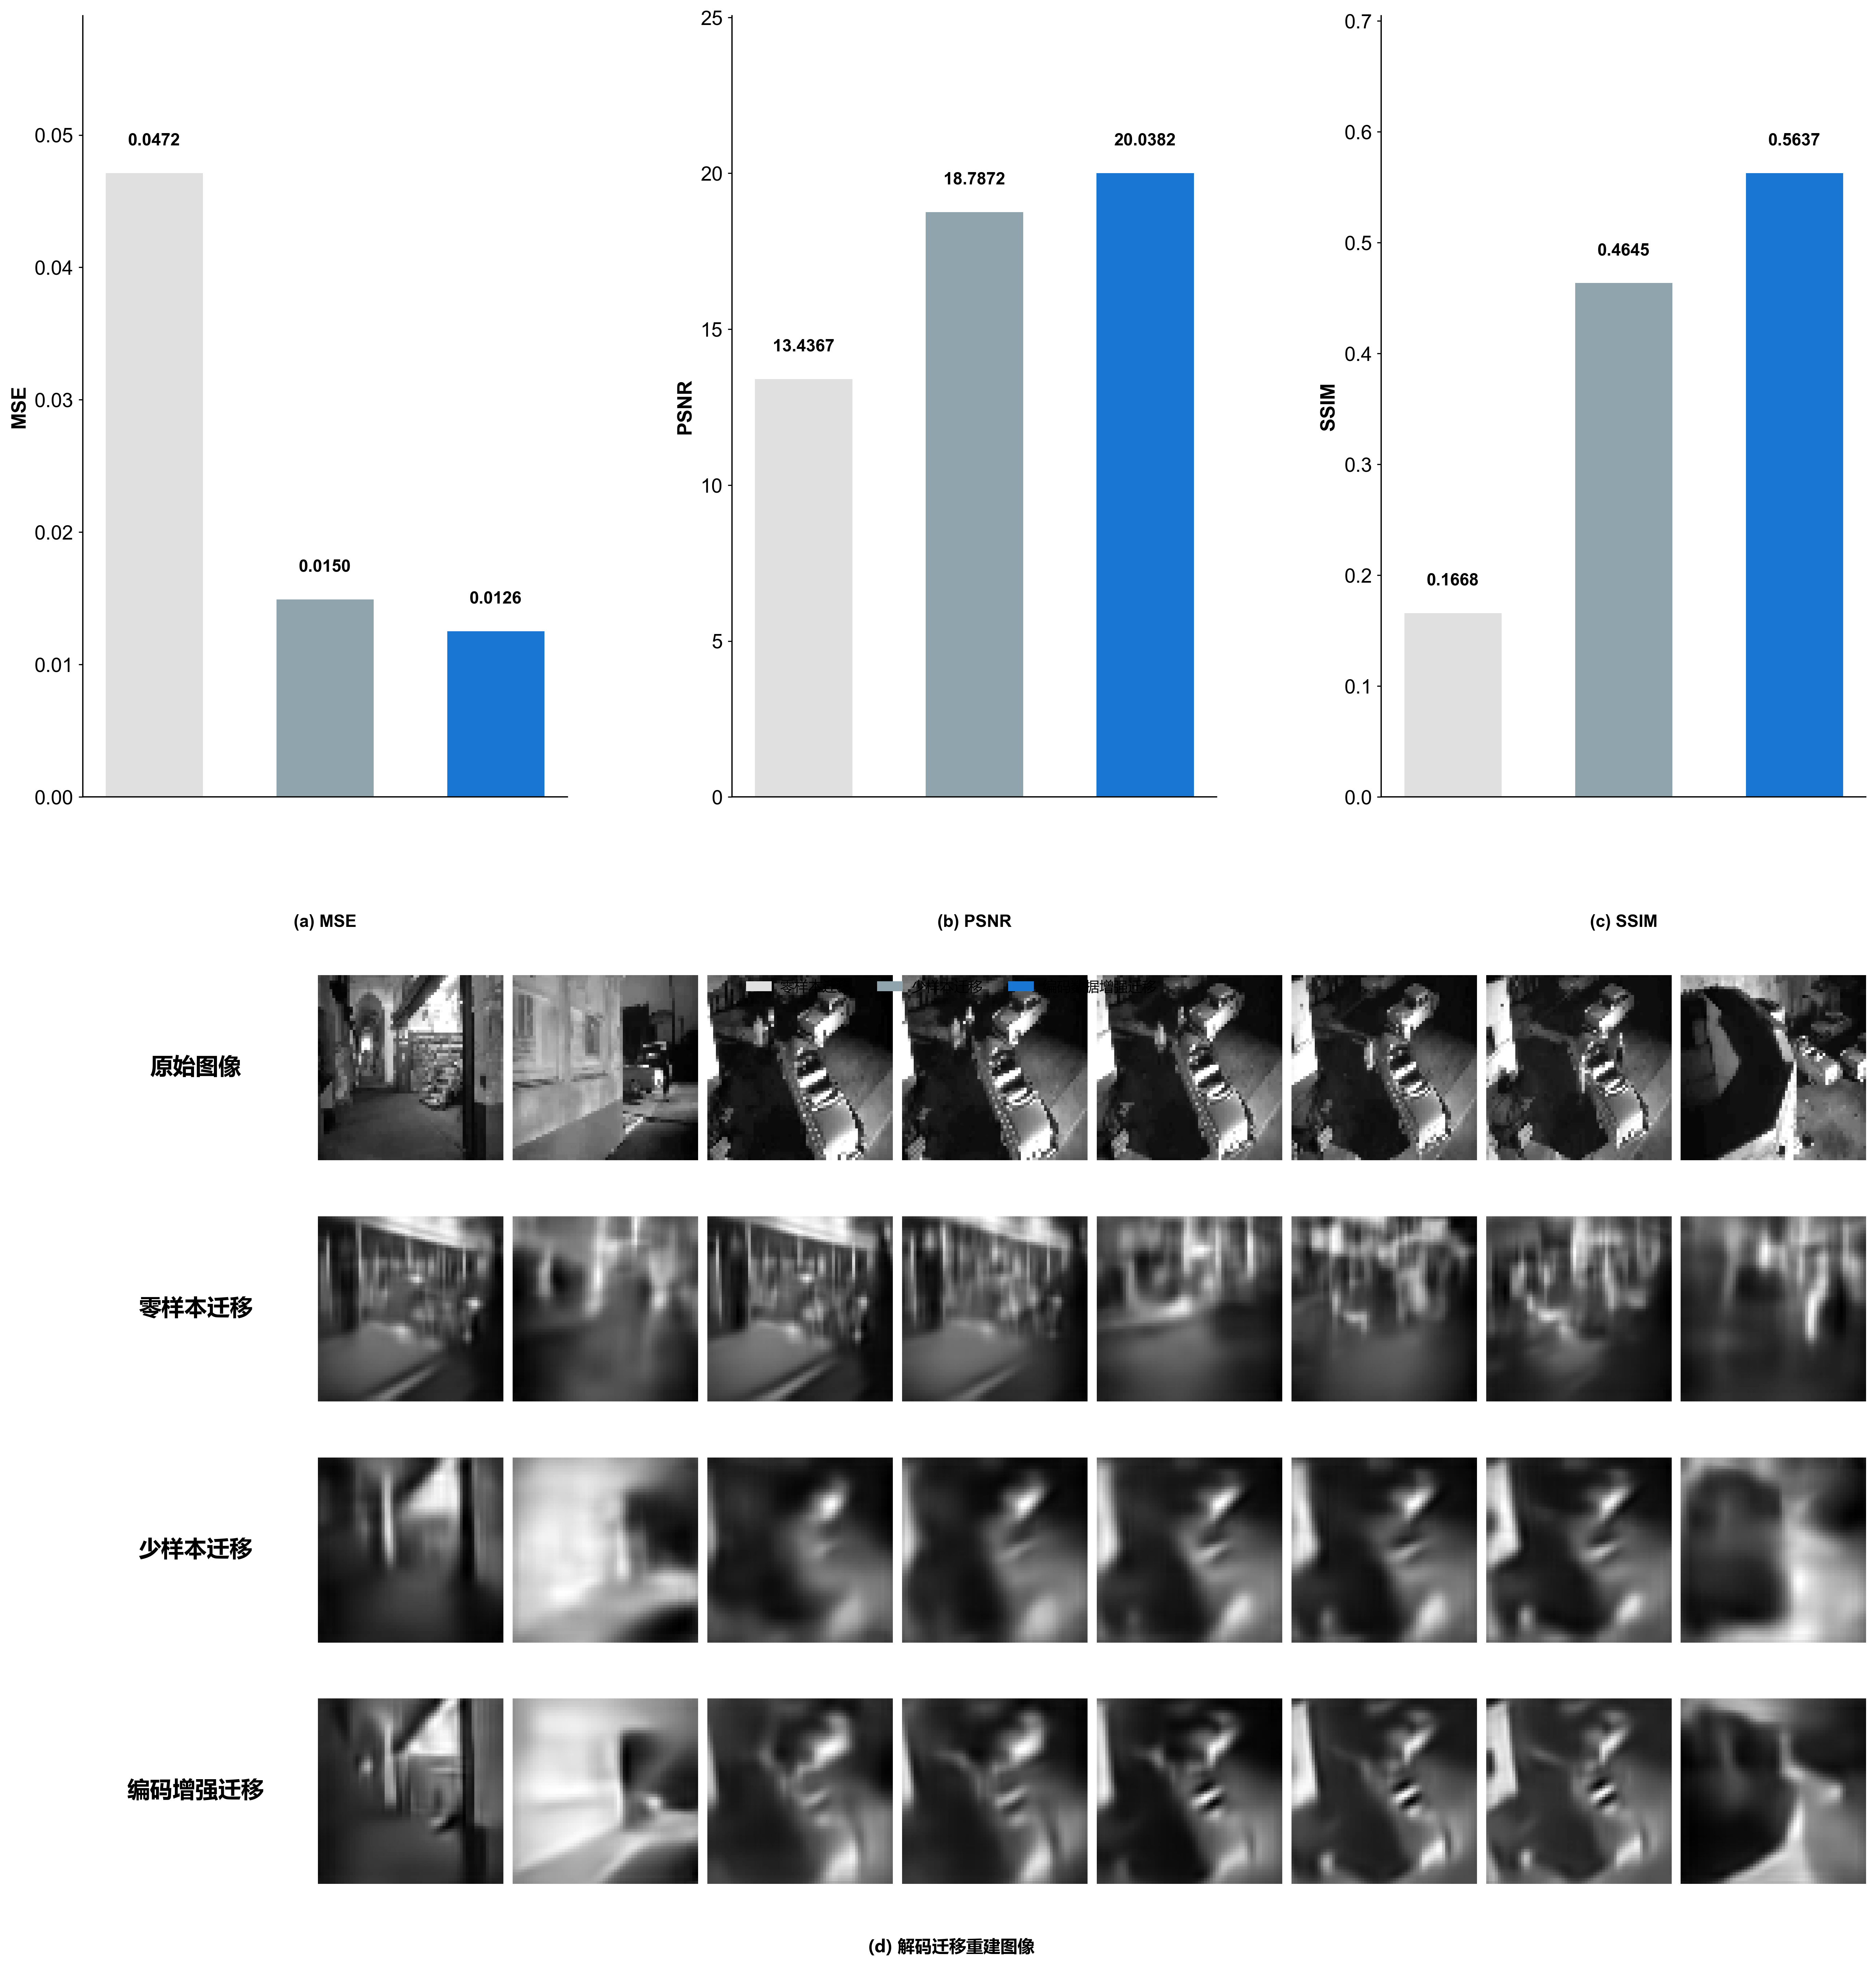

已生成合并图并保存为 movie1_metrics_and_comparison_combined.png / movie1_metrics_and_comparison_combined.pdf
对比图已显示完成


In [10]:
import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.font_manager import FontProperties
from matplotlib.patches import Rectangle
from PIL import Image

# -----------------------------
# Global publication styling
# -----------------------------
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'axes.unicode_minus': False,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'savefig.edgecolor': 'none',
})

cjk_font = FontProperties(family='Microsoft YaHei')

# -----------------------------
# Data
# -----------------------------
mse_vals = np.array([0.0472, 0.0150, 0.0126])
psnr_vals = np.array([13.4367, 18.7872, 20.0382])
ssim_vals = np.array([0.1668, 0.4645, 0.5637])

bar_colors = ['#E0E0E0', '#90A4AE', '#1976D2']
legend_labels = ['零样本迁移', '少样本迁移', '编码数据增强迁移']

# -----------------------------
# Paths for reconstruction grid
# -----------------------------
original_dir = Path(r'Neural_digit_twin\group1_movie3_only\movie1_reconstruction_combined\original_images')
group1_dir = Path(r'Neural_digit_twin\group1_movie3_only\movie1_reconstruction_combined\reconstructed_images')
group2_dir = Path(r'Neural_digit_twin\group2_movie3_plus_movie1_real\movie1_reconstruction\reconstructed_images')
group3_dir = Path(r'Neural_digit_twin\group3_pretrain_generated_then_finetune_real\movie1_reconstruction\reconstructed_images')

row_specs = [
    ('原始图像', original_dir),
    ('零样本迁移', group1_dir),
    ('少样本迁移', group2_dir),
    ('编码增强迁移', group3_dir),
]

def frame_key(name):
    match = re.search(r'frame_(\d+)\.png$', name)
    return int(match.group(1)) if match else math.inf

common_files = None
for _, folder in row_specs:
    names = {path.name for path in folder.glob('frame_*.png')}
    common_files = names if common_files is None else (common_files & names)

if not common_files:
    raise FileNotFoundError('未找到四个目录中都有的 frame_*.png 图像文件。')

common_list = sorted(common_files, key=frame_key)
num_to_show = min(8, len(common_list))
rng = np.random.default_rng()
selected = sorted(rng.choice(common_list, size=num_to_show, replace=False).tolist(), key=frame_key)

print(f'找到 {len(common_files)} 个公共帧，随机选择展示 {num_to_show} 帧')

# -----------------------------
# Figure layout
# -----------------------------
fig = plt.figure(figsize=(18, 19.8), dpi=300)
outer = fig.add_gridspec(
    nrows=2,
    ncols=1,
    height_ratios=[1.0, 1.22],
    hspace=0.18,
 )

# Top row: 3 bar charts
top_gs = outer[0].subgridspec(1, 3, wspace=0.34)
metrics = [
    ('MSE', mse_vals, '(a) MSE'),
    ('PSNR', psnr_vals, '(b) PSNR'),
    ('SSIM', ssim_vals, '(c) SSIM'),
]

title_size = 14
tick_size = 14
value_size = 12

for idx, (metric_name, values, panel_label) in enumerate(metrics):
    ax = fig.add_subplot(top_gs[0, idx])
    x = np.arange(len(values))
    bars = ax.bar(x, values, width=0.58, color=bar_colors, edgecolor='white', linewidth=1.2)

    ax.set_xticks([])
    ax.set_ylim(0, max(1e-6, float(values.max()) * 1.25))
    ax.set_ylabel(metric_name, fontsize=title_size, fontweight='bold')
    ax.tick_params(axis='y', labelsize=tick_size, width=0.8, length=3)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.9)
    ax.spines['bottom'].set_linewidth(0.9)

    y_pad = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.03
    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + y_pad,
            f'{value:.4f}',
            ha='center',
            va='bottom',
            fontsize=value_size,
            fontweight='bold',
        )

    ax.text(
        0.5,
        -0.15,
        panel_label,
        transform=ax.transAxes,
        ha='center',
        va='top',
        fontsize=12,
        fontweight='bold',
    )

# Single legend centered between top and bottom blocks
legend_handles = [Rectangle((0, 0), 1, 1, facecolor=color, edgecolor='none') for color in bar_colors]
fig.legend(
    legend_handles,
    legend_labels,
    loc='center',
    bbox_to_anchor=(0.5, 0.507),
    ncol=3,
    frameon=False,
    fontsize=13,
    prop=cjk_font,
    handlelength=1.8,
    handletextpad=0.6,
    columnspacing=1.8,
 )

# Bottom row: 4x8 reconstruction matrix
bottom_gs = outer[1].subgridspec(
    len(row_specs),
    num_to_show + 1,
    width_ratios=[1.22] + [1] * num_to_show,
    wspace=0.05,
    hspace=0.05,
 )

label_fontsize = 16

for row_idx, (row_label, folder) in enumerate(row_specs):
    label_ax = fig.add_subplot(bottom_gs[row_idx, 0])
    label_ax.axis('off')
    label_ax.text(
        0.5,
        0.5,
        row_label,
        ha='center',
        va='center',
        fontsize=label_fontsize,
        fontweight='bold',
        fontproperties=cjk_font,
    )

    for col_idx, name in enumerate(selected, start=1):
        ax = fig.add_subplot(bottom_gs[row_idx, col_idx])
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_frame_on(False)
        img = Image.open(folder / name).convert('RGB')
        if row_idx == 0:
            img = img.resize((64, 64), Image.Resampling.LANCZOS)
        ax.imshow(img)

# Bottom caption aligned with the top captions
fig.text(
    0.5,
    0.03,
    '(d) 解码迁移重建图像',
    ha='center',
    va='bottom',
    fontsize=12,
    fontweight='bold',
    fontproperties=cjk_font,
 )

# Tight but publication-friendly margins
plt.subplots_adjust(left=0.03, right=0.995, top=0.985, bottom=0.055)

combined_png = 'movie1_metrics_and_comparison_combined.png'
combined_pdf = 'movie1_metrics_and_comparison_combined.pdf'
fig.savefig(combined_png, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
fig.savefig(combined_pdf, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()

print(f'已生成合并图并保存为 {combined_png} / {combined_pdf}')
print('对比图已显示完成')


找到 890 个公共帧，选择展示前 8 帧


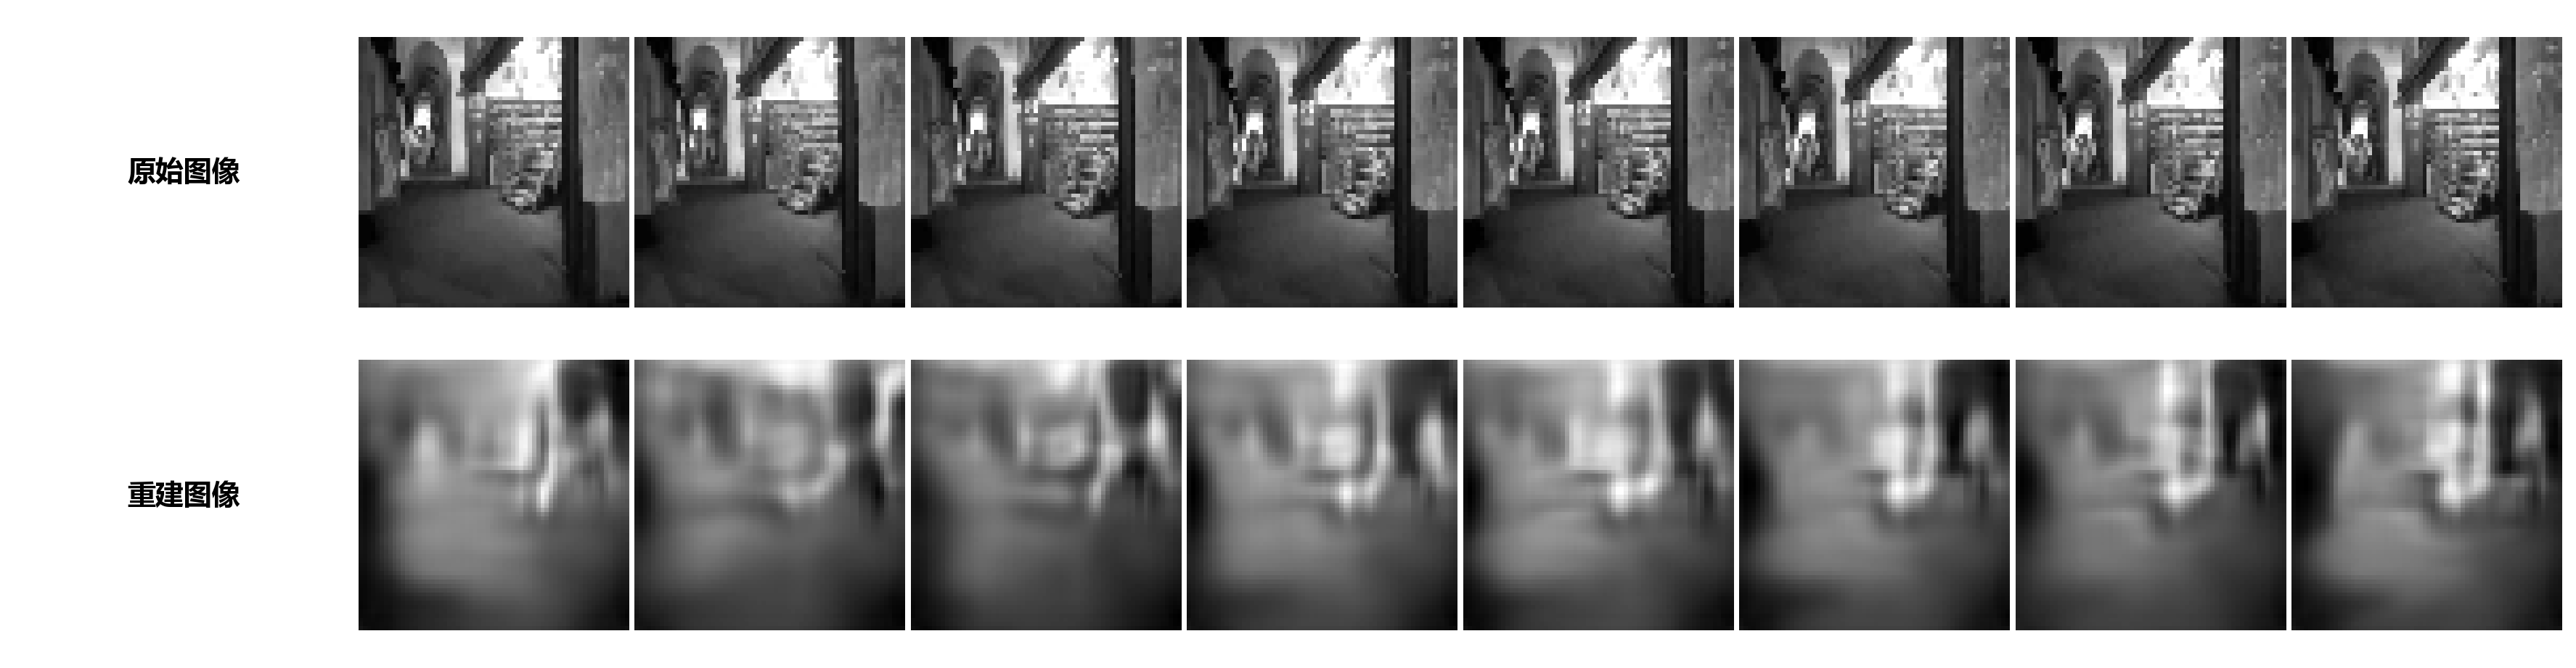

两行对比图已生成完成


In [1]:
# 两行对比图：原始图像 + 重建图像（对齐）
import re
import math
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# --- 配置路径 ---
original_dir = Path(r'Neural_digit_twin\group1_movie3_only\movie1_reconstruction_combined\original_images')
reconstructed_dir = Path(r'Neural_digit_twin\group1_movie3_only\movie1_reconstruction_combined\reconstructed_images')

output_dir = Path(r'Neural_digit_twin\comparison_all_groups')
output_dir.mkdir(parents=True, exist_ok=True)

row_specs = [
    ('原始图像', original_dir),
    ('重建图像', reconstructed_dir),
]

# --- 获取两个目录中的公共文件名 ---
common_files = None
for _, folder in row_specs:
    names = {p.name for p in folder.glob('frame_*.png')}
    common_files = names if common_files is None else common_files & names

if not common_files:
    raise FileNotFoundError('未找到两个目录中都有的 frame_*.png 图像文件。')

def frame_key(name):
    m = re.search(r'frame_(\d+)\.png$', name)
    return int(m.group(1)) if m else math.inf

# 按帧号排序并选择前 8 帧展示
common_list = sorted(common_files, key=frame_key)
num_to_show = min(8, len(common_list))
selected = common_list[:num_to_show]

print(f"找到 {len(common_files)} 个公共帧，选择展示前 {num_to_show} 帧")

# --- 创建两行对比图 ---
fig, axes = plt.subplots(
    nrows=len(row_specs),
    ncols=num_to_show + 1,
    figsize=(2.0 * (num_to_show + 1), 4.5),
    dpi=200,
    gridspec_kw={'width_ratios': [1.25] + [1] * num_to_show, 'wspace': 0.02, 'hspace': 0.02}
)

label_font = 'Microsoft YaHei'
label_size = 14

# 绘制两行
for row_idx, (row_label, folder) in enumerate(row_specs):
    # 第一列：标签
    label_ax = axes[row_idx, 0]
    label_ax.axis('off')
    label_ax.text(
        0.5, 0.5, row_label,
        ha='center', va='center',
        fontsize=label_size, fontweight='bold', fontname=label_font
    )
    
    # 后续列：对应的图像
    for col_idx, name in enumerate(selected, start=1):
        ax = axes[row_idx, col_idx]
        ax.axis('off')
        img_path = folder / name
        img = Image.open(img_path).convert('RGB')
        # 原始图像需要 resize 到 64x64
        if row_idx == 0:
            img = img.resize((64, 64), Image.Resampling.LANCZOS)
        ax.imshow(img)

plt.subplots_adjust(left=0.02, right=0.995, top=0.99, bottom=0.01, wspace=0.02, hspace=0.02)


# 在单元格中显示图片
%matplotlib inline
plt.show()
print('两行对比图已生成完成')